# From EEG Features to a COMPASS Prediction: Ontology, Ingestion, and the Tier Ladder

Stage three turns the extracted features into a linguistic, hierarchical representation the COMPASS engine
can reason over, and runs the engine on 10 subjects (5 first-episode-psychosis, 5 control) across a
five-tier evidence ladder.

**The integrated task** is one mixed-type hierarchy:

- root: **diagnosis** (binary: Control vs First-Episode Psychosis)
  - **global severity**: BPRS 19-item total (univariate regression)
    - **positive symptoms**: 4 SAPS global ratings (multivariate)
    - **negative symptoms**: 5 SANS global ratings (multivariate)

Every node is predicted for every subject; the symptom nodes simply have no ground truth for controls,
which is expected.

**The evidence ladder** (each tier is the bundle written into the participant's four COMPASS files):

| Tier | Evidence | Purpose |
|------|----------|---------|
| T1 | demographics + socio-economic status | proxy floor |
| T2 | + cognition, IQ, observed functioning (all non-neural) | clinical profile |
| T3 | + all 836 EEG features | full multimodal ceiling |
| T4 | psychosis-implicated lean EEG only | hypothesis-driven neural floor |
| T5 | all 836 EEG only | pure neural ceiling |

Reading: T1 to T2 is the proxy gain, T2 to T3 is the neural lift, T4 vs T5 is lean-vs-rich, T3 vs T5 is
the value of non-neural context.

This is a demonstration on 10 subjects with a small model; the metrics are illustrative of the pipeline,
not a definitive validation.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

DATASET_ROOT = Path.cwd()
if DATASET_ROOT.name == "notebooks":
    DATASET_ROOT = DATASET_ROOT.parent
sys.path.insert(0, str(DATASET_ROOT))

from utils import compass_task as K, compass_viz as CV
from utils.features import build_schema
_, eeg_names = build_schema()
eeg = pd.read_csv(K.RESULTS_ROOT / "eeg_features.csv")
non_eeg = pd.read_csv(K.RESULTS_ROOT / "non_eeg_features.csv")
frame = K.build_merged_frame(eeg, non_eeg)
groups = K.resolve_predictor_groups(non_eeg, eeg_names)
tiers = K.build_tiers(groups)
print(f"cohort: {len(frame)} recordings | predictor groups: "
      + ", ".join(f"{k}={len(v)}" for k, v in groups.items() if k != 'eeg_rich'))

/Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/compass_engine/validation/datasets/PSYCHOSIS_FIRST_EPISODE/utils/features.py:37: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


cohort: 143 recordings | predictor groups: demographics=4, ses=4, cognition=11, functioning=6, social=74, eeg_lean=29


## 1. The prediction task

The single `PredictionTaskSpec` below is the mixed-type hierarchy. The root is a binary classification;
its descendants are regressions. The engine walks this tree and returns a prediction at every node.

In [2]:
spec = K.build_task_spec()
def show_node(node, depth=0):
    pad = "  " * depth
    detail = (f"[{node.mode.value}] " + (", ".join(node.class_labels) if node.class_labels
              else f"{len(node.regression_outputs)} output(s)"))
    print(f"{pad}- {node.node_id}: {node.display_name}\n{pad}    {detail}")
    for c in node.children:
        show_node(c, depth + 1)
show_node(spec.root)
print(f"\ntotal outputs harvested per subject: 1 diagnosis + {len(K.ALL_OUTPUTS)} regression values")

- diagnosis: First-Episode Psychosis vs Control
    [binary_classification] Control, First-Episode Psychosis
  - global_severity: Overall psychiatric symptom severity (BPRS 19-item total)
      [univariate_regression] 1 output(s)
    - positive_symptoms: SAPS positive-symptom global ratings
        [multivariate_regression] 4 output(s)
    - negative_symptoms: SANS negative-symptom global ratings
        [multivariate_regression] 5 output(s)

total outputs harvested per subject: 1 diagnosis + 10 regression values


## 2. Tiers and leakage control

Each tier names its predictor columns. The excluded columns can never be predictors in any tier: the
label itself, every BPRS/SANS/SAPS item (they are targets and psychosis-only), the global assessment
scale and the SFS employment block (control-sparse, so their missingness would leak the label), and the
chlorpromazine equivalent (psychosis-only). Every remaining predictor is present for both groups.

In [3]:
tier_tbl = pd.DataFrame([{"tier": t["id"], "label": t["label"], "n_predictors": len(t["columns"])}
                         for t in tiers])
print(tier_tbl.to_string(index=False))
excl = K.excluded_columns(non_eeg)
from collections import Counter
print(f"\nexcluded from every tier: {len(excl)} columns")
for reason, n in Counter(excl.values()).items():
    print(f"  {n:3d}  {reason}")
print(f"\nlean EEG set (T4): {len(groups['eeg_lean'])} psychosis-implicated features, e.g.:")
for c in groups['eeg_lean'][:6]:
    print("   ", c)

                        tier                                        label  n_predictors
T1_demographic_socioeconomic     T1: demographics + socio-economic status             8
         T2_clinical_profile    T2: + cognition, IQ, observed functioning            99
          T3_multimodal_full T3: + all 836 EEG features (full multimodal)           935
                 T4_eeg_lean       T4: psychosis-implicated lean EEG only            29
                 T5_eeg_rich                         T5: all 836 EEG only           836

excluded from every tier: 90 columns
    2  root label
    1  psychosis-only (leaks label)
   81  symptom target / psychosis-only
    1  control-sparse (leaks label)
    5  employment block, control-sparse (leaks label)

lean EEG set (T4): 29 psychosis-implicated features, e.g.:
    A_spectral__log10_absolute_power_uv2__alpha_8_13_hz__global
    A_spectral__log10_absolute_power_uv2__alpha_8_13_hz__occipital_left
    A_spectral__log10_absolute_power_uv2__alpha_8_13_hz

## 3. The ontology (the linguistic representation)

Every predictor column is a leaf of an arbitrary-depth ontology. The 836 EEG features are placed
deterministically by an explicit path (family, measure, band, region); the non-neural clinical predictors
are grouped semantically by the LLM (an OpenRouter model) from their names and descriptions. The result
is one master ontology, quality-assessed and emitted as the full linguistic representation under
`results/compass/ontology/`:

- `subclass_structure.json` - machine-readable ontology and column index
- `psychosis_fep.owl` - Protege-loadable OWL (RDF/XML)
- `ontology_viewer.html` - self-contained interactive explorer
- `ontology_features.csv` - every recording with hierarchy-encoded column names
- `exploration_report.json` and `ontology_report.json` - automated data understanding and QA

Each tier is a clean projection of this master ontology onto that tier's columns.

In [4]:
onto_path = K.ONTOLOGY_DIR / "subclass_structure.json"
ontology = json.loads(onto_path.read_text())
report = json.loads((K.ONTOLOGY_DIR / "ontology_report.json").read_text())
def count_leaves(node):
    ch = node.get("children")
    return 1 if not ch else sum(count_leaves(c) for c in ch)
print(f"ontology: {report['n_domains']} domains, {report['n_internal_nodes']} internal nodes, "
      f"{report['n_features']} leaves, max depth {report['max_depth']}")
ari = (report.get("cluster_agreement") or {}).get("adjusted_rand_index")
rev = report.get("llm_review") or {}
print(f"QA: cluster agreement ARI={ari} (semantic vs statistical clusters), "
      f"LLM MECE ok={rev.get('mece_ok')}, coherence={rev.get('coherence_1to5')}/5")
print("\ndomains:")
for dom in ontology["domains"]:
    print(f"  {dom['label']}: {count_leaves(dom)} leaves, {len(dom.get('children', []))} subdomains")

clinical = [d for d in ontology["domains"] if "EEG" not in d["label"]]
if clinical:
    d = clinical[0]
    print(f"\nexample structure - {d['label']}:")
    for sub in d.get("children", [])[:6]:
        kids = [c["label"] for c in sub.get("children", [])][:5]
        print(f"  {sub['label']}: {', '.join(kids)}" + (" ..." if len(sub.get('children', [])) > 5 else ""))
artifacts = sorted(p.name for p in K.ONTOLOGY_DIR.iterdir())
print(f"\nlinguistic-representation artifacts: {artifacts}")

ontology: 4 domains, 103 internal nodes, 935 leaves, max depth 5
QA: cluster agreement ARI=0.161 (semantic vs statistical clusters), LLM MECE ok=True, coherence=5/5

domains:
  Resting-State EEG: 836 leaves, 8 subdomains
  Demographics and Socio-economic Status: 8 leaves, 2 subdomains
  Observed Functioning: 80 leaves, 2 subdomains
  Cognition and Intelligence: 11 leaves, 2 subdomains

example structure - Demographics and Socio-economic Status:
  Participant Demographics: Age Years, Ethnicity Source Reported, Race Source Reported, Sex Source Reported
  Socio-economic Status: Father Hollingshead Index, Mother Hollingshead Index, Parental Mean Hollingshead Index, Participant Hollingshead Index

linguistic-representation artifacts: ['exploration_report.json', 'ontology.json', 'ontology_features.csv', 'ontology_report.json', 'ontology_viewer.html', 'psychosis_fep.owl', 'subclass_structure.json']


## 4. The four COMPASS input files

Each subject-tier folder holds the engine's native contract: `multimodal_data.json` (values and z-scores
at every leaf), `hierarchical_deviation_map.json` (signed deviation at every node), `data_overview.json`
(coverage and token budget per node), and `non_numerical_data.txt` (a compact narrative). Predictor
deviations are cohort z-scores referenced to the disjoint reference split. Below is one subject's T3
bundle.

In [5]:
# The 10-subject x 5-tier ladder is cached. To re-run it (uses OpenRouter credits,
# about 2 USD), set RERUN_LADDER = True and re-execute this cell; it rebuilds the
# ontology artifacts, writes the four input files, and runs the 50 predictions.
RERUN_LADDER = False
pred_path = K.LADDER_DIR / "predictions.json"
if RERUN_LADDER or not pred_path.exists():
    import subprocess
    subprocess.run([sys.executable, "-m", "utils.run_ladder", "--workers", "4", "--max-usd", "5"],
                   cwd=str(DATASET_ROOT), check=True)
pred_payload = CV.load_predictions(pred_path)
example_id = pred_payload["cohort"]["psychosis"][0]
sub_dir = K.INPUTS_DIR / "T3_multimodal_full" / example_id
for fname in ["data_overview.json", "hierarchical_deviation_map.json", "multimodal_data.json"]:
    obj = json.loads((sub_dir / fname).read_text())
    print(f"{fname}: top-level keys = {list(obj.keys())[:6]}")
ov = json.loads((sub_dir / "data_overview.json").read_text())
print(f"\n{example_id} T3: {ov['present_leaves']}/{ov['total_leaves']} leaves present, "
      f"~{ov['total_tokens']} tokens")
print("\nnarrative excerpt:")
print("\n".join((sub_dir / "non_numerical_data.txt").read_text().splitlines()[:14]))

data_overview.json: top-level keys = ['participant_id', 'reference_mode', 'domain_coverage', 'total_tokens', 'total_leaves', 'present_leaves']
hierarchical_deviation_map.json: top-level keys = ['Resting_EEG', 'DEMOGRAPHICS_AND_SOCIOECONOMIC', 'OBSERVED_FUNCTIONING', 'COGNITION_AND_INTELLIGENCE']
multimodal_data.json: top-level keys = ['Resting_EEG', 'DEMOGRAPHICS_AND_SOCIOECONOMIC', 'OBSERVED_FUNCTIONING', 'COGNITION_AND_INTELLIGENCE']

ds003947_sub-2477A T3: 935/935 leaves present, ~21100 tokens

narrative excerpt:
Participant ID: ds003947_sub-2477A
Source: blinded evaluation record from PSYCHOSIS_FEP; non-cognitive multimodal features only.
Reference strategy: cohort (deviation from the population cohort).

TARGET MEASUREMENT REFERENCE:
Predict whether this resting-EEG participant is a first-episode-psychosis case or a control, then predict their psychiatric symptom severity on the native clinical scales below.

Symptom scales (predict on these native ranges; no symptom value for thi

## 5. Cohort and the ladder run

Ten subjects (5 psychosis spread across BPRS severity, 5 controls) are the evaluation set; the other 133
recordings form the disjoint reference split used to standardize predictors and to calibrate the target
scales in the global instruction. The 50 predictions (10 subjects x 5 tiers) were run by
`python -m utils.run_ladder` and cached; this notebook loads them.

In [6]:
payload = pred_payload
frame_pred = CV.to_frame(payload)
n_ok = sum(1 for r in payload['predictions'] if not r.get('error'))
print(f"cohort: {len(payload['cohort']['psychosis'])} psychosis, {len(payload['cohort']['control'])} control")
print(f"model: {payload['model']}")
print(f"runs: {payload['n_runs']} ({n_ok} succeeded)"
      + (f" | OpenRouter spend: ${payload['usd_spent']}" if payload.get('usd_spent') is not None else ""))
print("\nreference target calibration (native scales, from the disjoint split):")
for c, s in list(payload["reference_stats"].items())[:3]:
    print(f"  {c.split('__')[-1][:40]}: mean={s['mean']} sd={s['sd']} (n={s['n']})")

cohort: 5 psychosis, 5 control
model: google/gemini-3.1-flash-lite
runs: 50 (50 succeeded) | OpenRouter spend: $1.8975

reference target calibration (native scales, from the disjoint split):
  total_q01_to_q19: mean=46.77 sd=8.64 (n=74)
  q07_global_rating_of_hallucinations: mean=1.76 sd=1.4 (n=74)
  q20_global_rating_of_delusions: mean=2.61 sd=1.14 (n=74)


## 6. Diagnosis recovery across the ladder

Balanced accuracy and AUROC for the root diagnosis node at each tier, and the per-subject probability of
psychosis. On 10 subjects these are coarse, but they show the engine responding to the evidence bundle.

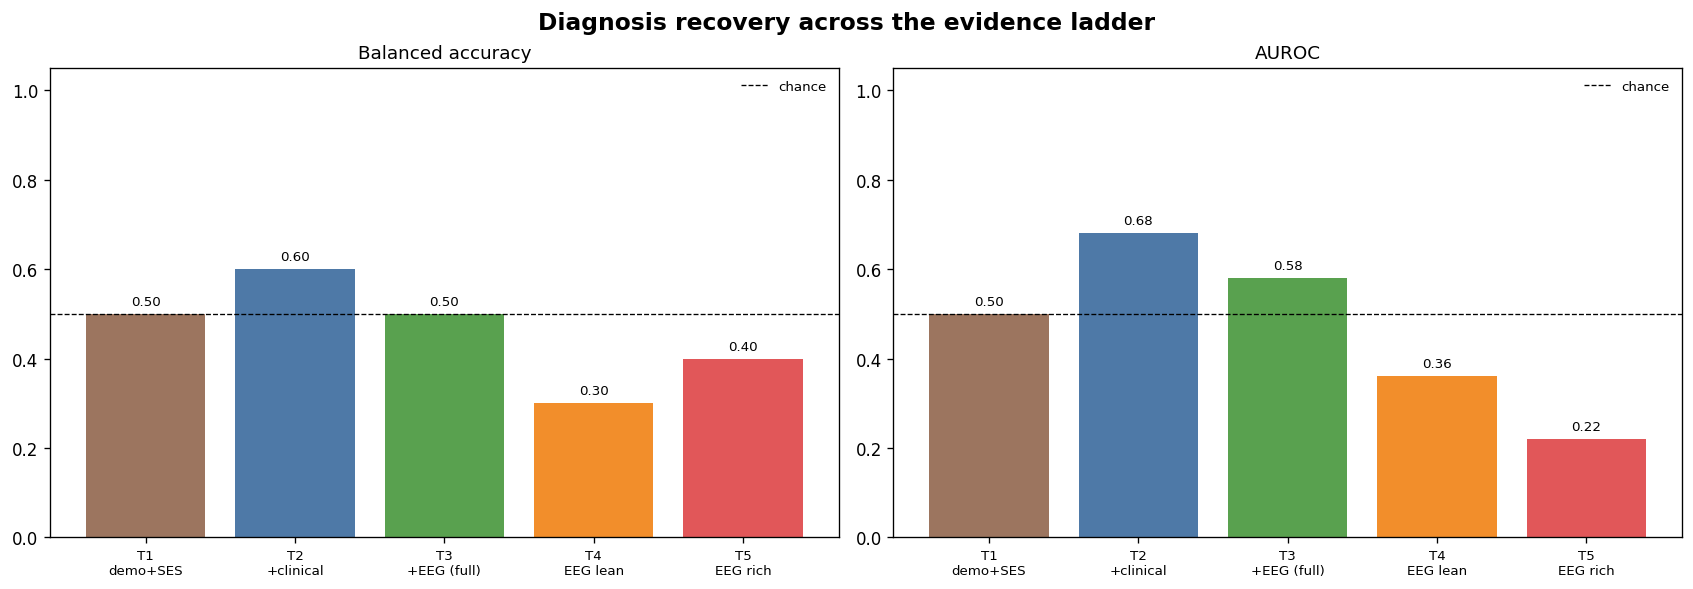

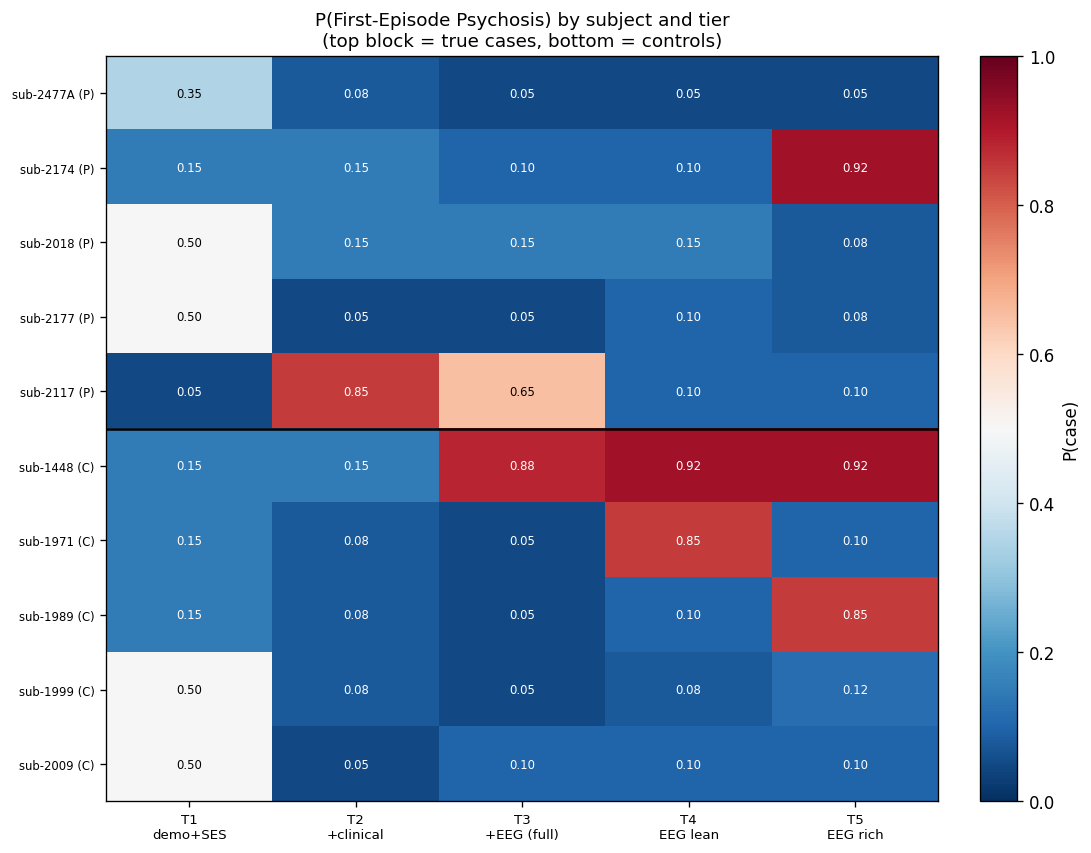

In [7]:
FIG = K.LADDER_DIR / "figures"; FIG.mkdir(parents=True, exist_ok=True)
fig = CV.fig_diagnosis_ladder(frame_pred); fig.savefig(FIG / "diagnosis_ladder.png", dpi=130, bbox_inches="tight"); plt.show()
fig = CV.fig_diagnosis_heatmap(frame_pred, payload); fig.savefig(FIG / "diagnosis_heatmap.png", dpi=130, bbox_inches="tight"); plt.show()

## 7. Nested symptom-severity recovery

Under the diagnosis root, the engine predicts BPRS total severity and, beneath it, the SAPS positive and
SANS negative symptom globals. Symptom recovery is scored only on rated (psychosis) subjects; controls are
predicted but have no symptom ground truth.

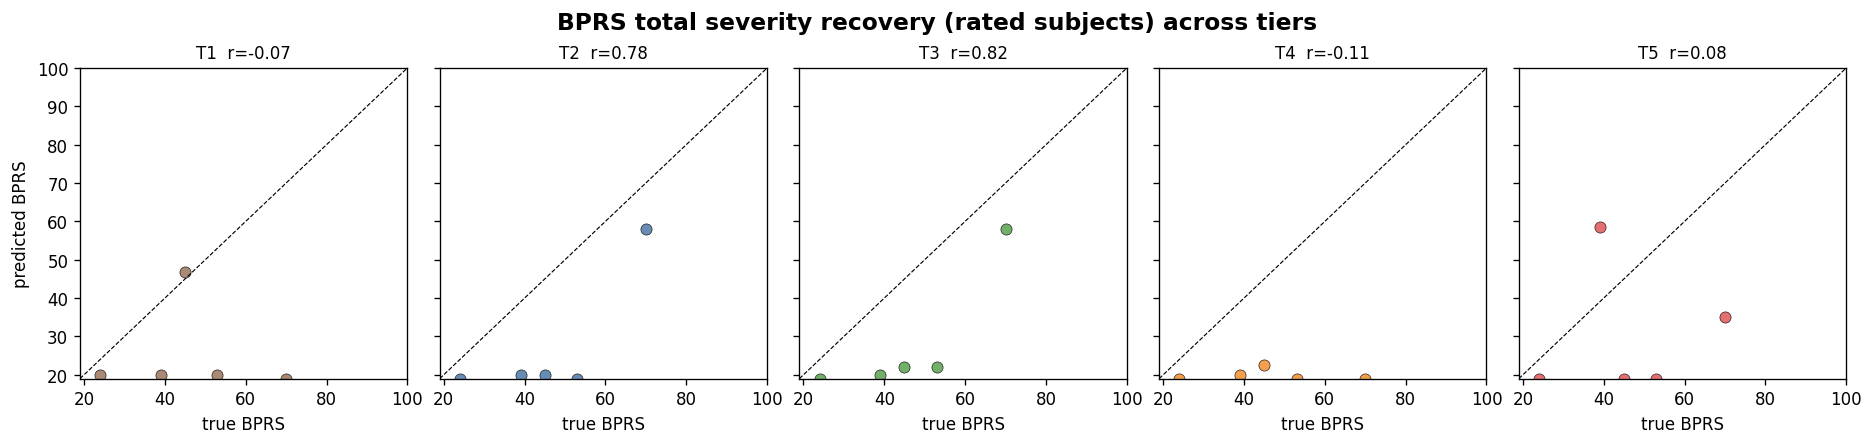

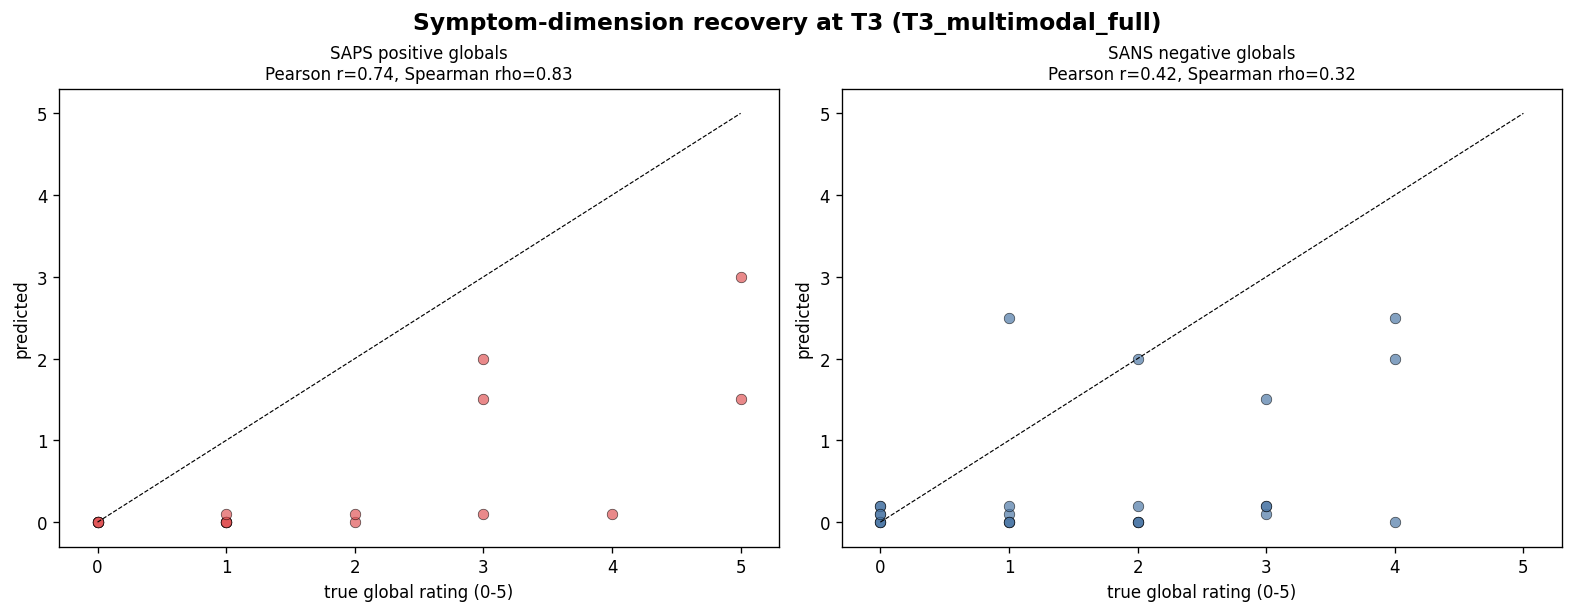

In [8]:
fig = CV.fig_symptom_recovery(frame_pred); fig.savefig(FIG / "symptom_bprs.png", dpi=130, bbox_inches="tight"); plt.show()
fig = CV.fig_symptom_dimensions(frame_pred, tier="T3_multimodal_full"); fig.savefig(FIG / "symptom_dimensions.png", dpi=130, bbox_inches="tight"); plt.show()

## 8. Reading the ladder

The diagnosis balanced accuracy along the ladder, with the key contrasts marked: proxy gain (T1 to T2),
neural lift (T2 to T3), and lean vs rich EEG (T4 vs T5).

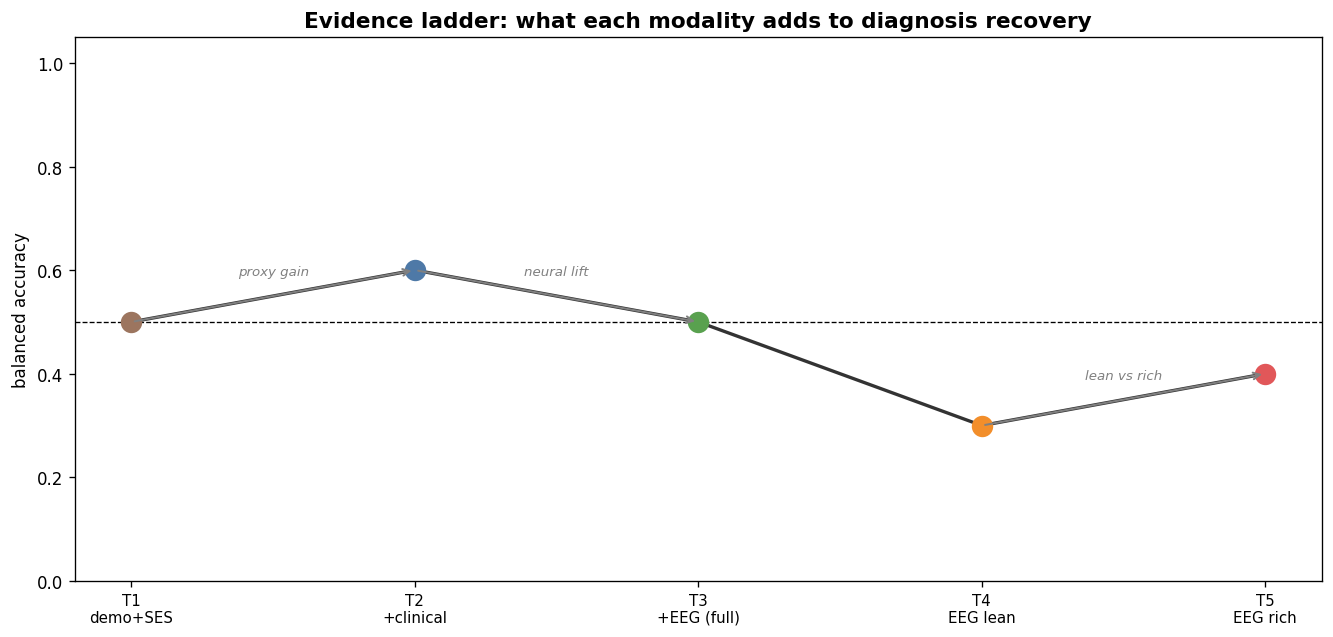

In [9]:
fig = CV.fig_ladder_reading(frame_pred); fig.savefig(FIG / "ladder_reading.png", dpi=130, bbox_inches="tight"); plt.show()

## 9. One subject's full hierarchical prediction

The complete mixed-type prediction tree for a representative psychosis subject at the full multimodal
tier: the diagnosis, the BPRS total beneath it, and the SAPS/SANS globals beneath that, each predicted
value shown against ground truth.

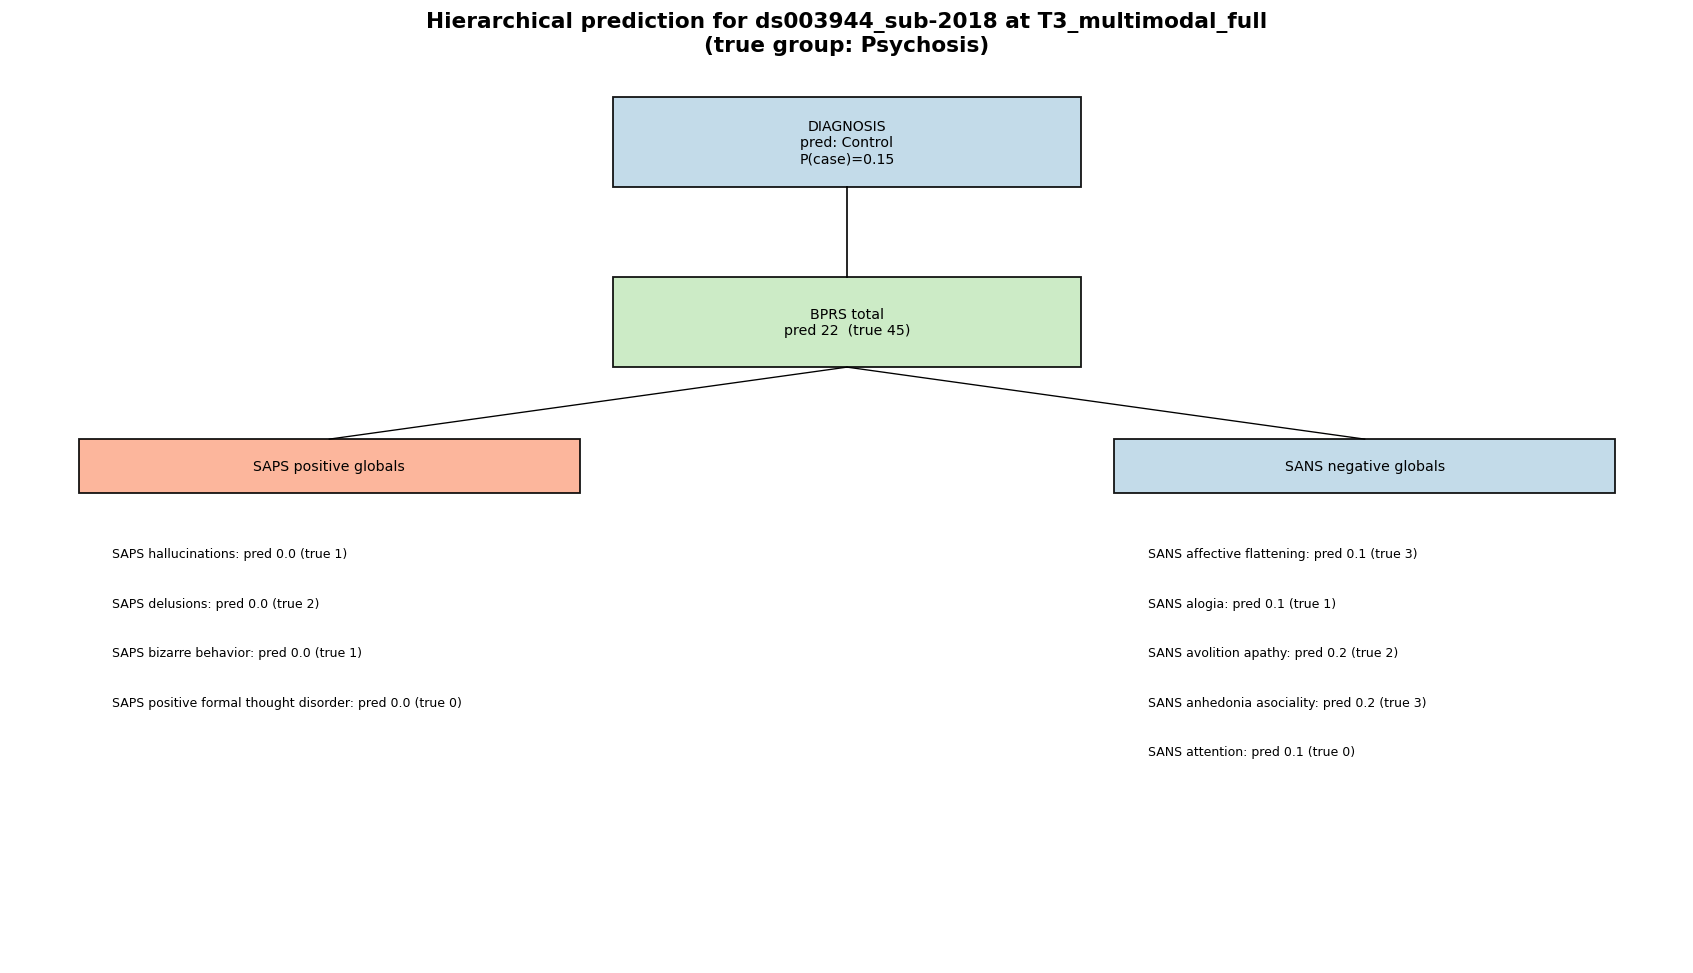

In [10]:
fig = CV.fig_hierarchy_tree(frame_pred, payload, tier="T3_multimodal_full")
fig.savefig(FIG / "hierarchy_tree.png", dpi=130, bbox_inches="tight"); plt.show()

## 10. Summary

The pipeline built a linguistic ontology over the EEG and clinical features, wrote the four COMPASS input
files per subject per tier with leakage-controlled predictors and disjoint-reference z-scores, and ran the
integrated diagnosis-plus-symptom hierarchy on 10 subjects across five evidence tiers. The full-cohort run
is a single command: `python -m utils.run_ladder`.

In [11]:
metrics = CV.diagnosis_metrics(frame_pred)
print(metrics.to_string(index=False))
print(f"\ninput files written under: {K.INPUTS_DIR.relative_to(K.RESULTS_ROOT.parent)}")
print(f"predictions cached at:     {(K.LADDER_DIR / 'predictions.json').relative_to(K.RESULTS_ROOT.parent)}")

                        tier  balanced_accuracy  auroc  n
T1_demographic_socioeconomic                0.5   0.50 10
         T2_clinical_profile                0.6   0.68 10
          T3_multimodal_full                0.5   0.58 10
                 T4_eeg_lean                0.3   0.36 10
                 T5_eeg_rich                0.4   0.22 10

input files written under: results/compass/inputs
predictions cached at:     results/compass/ladder/predictions.json
